In [2]:
# Install Ultralytics (YOLOv8 library) and other tools
!pip install Ultralytics
!pip install gitpython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.9 MB/s eta 0:00:00


In [6]:
import torch

In [7]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
!git clone https://github.com/lugan113/TXL-PBC_Dataset.git /content/TXL-PBC_Dataset
LOCAL = '/content/TXL-PBC_Dataset'

Cloning into '/content/TXL-PBC_Dataset'...
remote: Enumerating objects: 4313, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 4313 (delta 7), reused 0 (delta 0), pack-reused 4296 (from 1)
Receiving objects: 100% (4313/4313), 89.39 MiB | 16.30 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [18]:

import yaml

LOCAL_ROOT = '/content/TXL-PBC_Dataset/TXL-PBC'   # correct path

cfg = {
    'path'  : LOCAL_ROOT,
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : 3,
    'names' : ['WBC', 'RBC', 'Platelets']
}

yaml_path = '/content/TXL-PBC_Dataset/TXL-PBC/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)
print(yaml.dump(cfg))

names:
- WBC
- RBC
- Platelets
nc: 3
path: /content/TXL-PBC_Dataset/TXL-PBC
test: images/test
train: images/train
val: images/val



# EDA : Explore the Dataset

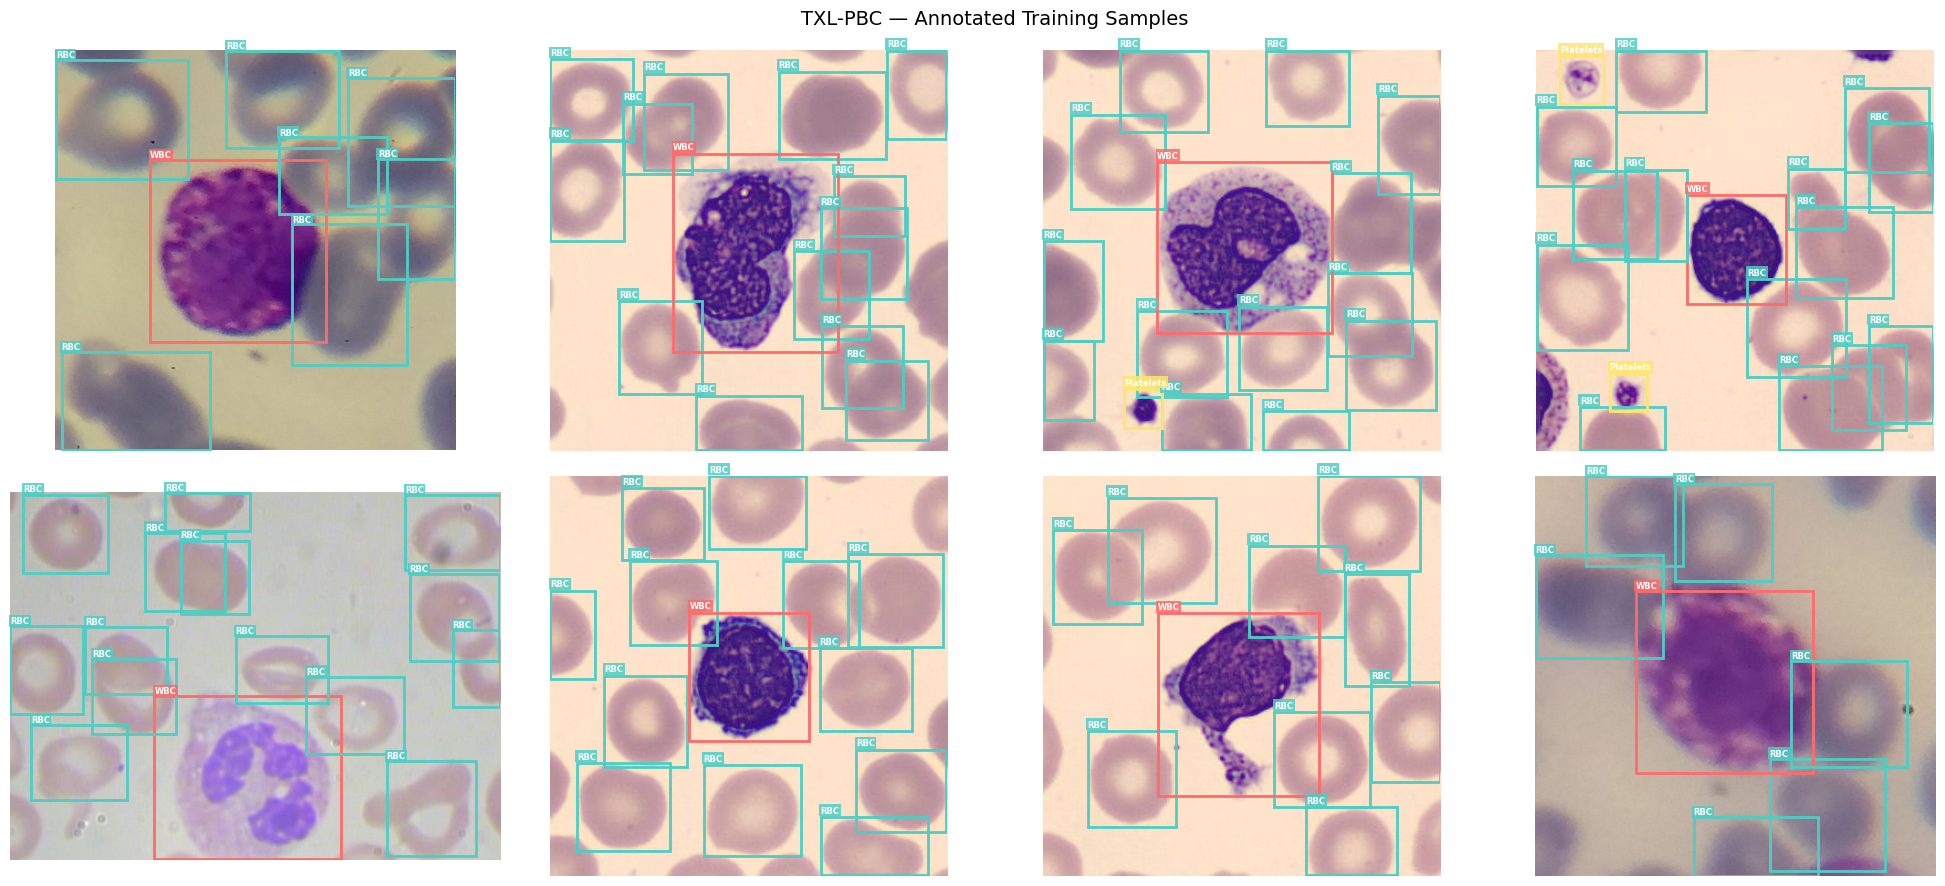

Saved → figures/01_samples.png

Class distribution:
              WBC      RBC  Platelets    Total
──────────────────────────────────────────────
train         908    11220        382    12510
val           257     3383        112     3752
test          133     1699         49     1881


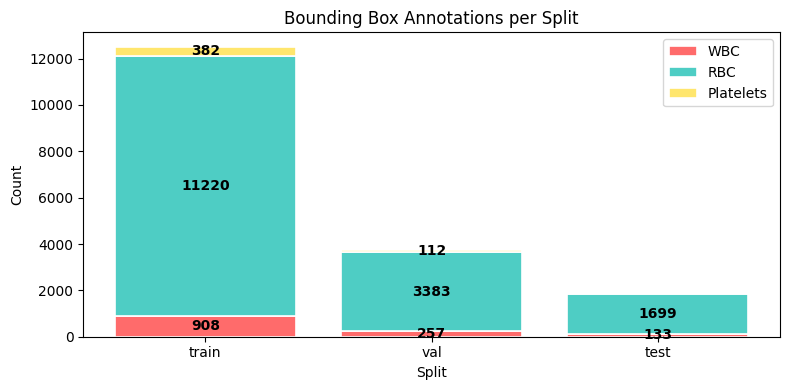

Saved → figures/02_class_dist.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from collections import Counter
import random, os

random.seed(42)

# ── Define these here so the cell is self-contained ──────────────
LOCAL_ROOT = '/content/TXL-PBC_Dataset/TXL-PBC'
CLASS_NAMES = ['WBC', 'RBC', 'Platelets']          # matches your yaml exactly
COLORS      = {'WBC':'#FF6B6B', 'RBC':'#4ECDC4', 'Platelets':'#FFE66D'}
COLOR_LIST  = [COLORS[n] for n in CLASS_NAMES]

os.makedirs('figures', exist_ok=True)

# ── 1. Annotated sample grid ──────────────────────────────────────
def draw_boxes(img_path, lbl_path, ax):
    img  = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                x1, y1 = (cx - bw/2)*W, (cy - bh/2)*H
                ax.add_patch(patches.Rectangle(
                    (x1, y1), bw*W, bh*H,
                    linewidth=2, edgecolor=COLOR_LIST[cls], facecolor='none'))
                ax.text(x1, y1-4, CLASS_NAMES[cls],
                        color='white', fontsize=6, fontweight='bold',
                        bbox=dict(facecolor=COLOR_LIST[cls], alpha=0.85,
                                  pad=1, edgecolor='none'))
    ax.axis('off')

train_img = os.path.join(LOCAL_ROOT, 'images', 'train')
train_lbl = os.path.join(LOCAL_ROOT, 'labels', 'train')

# Filter only image files
all_imgs  = [f for f in os.listdir(train_img)
             if f.lower().endswith(('.jpg','.jpeg','.png'))]
imgs      = random.sample(all_imgs, min(8, len(all_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, fname in zip(axes.flatten(), imgs):
    stem = os.path.splitext(fname)[0]
    draw_boxes(os.path.join(train_img, fname),
               os.path.join(train_lbl, stem + '.txt'), ax)

plt.suptitle('TXL-PBC — Annotated Training Samples', fontsize=14)
plt.tight_layout()
plt.savefig('figures/01_samples.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → figures/01_samples.png')

# ── 2. Class distribution ─────────────────────────────────────────
def count_labels(lbl_dir):
    c = Counter()
    for f in os.listdir(lbl_dir):
        if f.endswith('.txt'):
            for line in open(os.path.join(lbl_dir, f)):
                if line.strip():
                    c[int(line.split()[0])] += 1
    return c

split_counts = {}
print('\nClass distribution:')
print(f'{"":8} {"WBC":>8} {"RBC":>8} {"Platelets":>10} {"Total":>8}')
print('─' * 46)
for split in ['train', 'val', 'test']:
    c     = count_labels(os.path.join(LOCAL_ROOT, 'labels', split))
    split_counts[split] = c
    total = sum(c.values())
    print(f'{split:8} {c[0]:>8} {c[1]:>8} {c[2]:>10} {total:>8}')

# ── Stacked bar chart ─────────────────────────────────────────────
fig, ax  = plt.subplots(figsize=(8, 4))
splits   = list(split_counts.keys())
bottoms  = np.zeros(len(splits))

for i, name in enumerate(CLASS_NAMES):
    vals = [split_counts[s][i] for s in splits]
    bars = ax.bar(splits, vals, bottom=bottoms, color=COLOR_LIST[i],
                  label=name, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        if val > 50:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    str(val), ha='center', va='center',
                    fontsize=10, fontweight='bold', color='black')
    bottoms += np.array(vals, dtype=float)

ax.set(title='Bounding Box Annotations per Split',
       ylabel='Count', xlabel='Split')
ax.legend()
plt.tight_layout()
plt.savefig('figures/02_class_dist.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → figures/02_class_dist.png')

# Training


In [20]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
results = model.train(
    data         = yaml_path,
    epochs       = 50,
    imgsz        = 640,
    batch        = 8,
    optimizer    = 'AdamW',
    lr0          = 0.001,     # initial learning rate
    lrf          = 0.01,      # final lr = lr0 * lrf
    warmup_epochs= 3,
    weight_decay = 0.0005,
    # Augmentation tuned for microscopy images
    hsv_h   = 0.015,          # stain color variation
    hsv_s   = 0.7,
    hsv_v   = 0.4,
    degrees = 10.0,           # cells appear at any rotation
    flipud  = 0.5,
    fliplr  = 0.5,
    mosaic  = 1.0,
    # Output
    project  = 'blood_yolo',
    name     = 'yolov8s_txlpbc',
    exist_ok = True,
    plots    = True,
    save     = True,
    cache    = True,
    workers  = 2,
    device   = 0,
)

SAVE_DIR = str(results.save_dir)
BEST_PT  = os.path.join(SAVE_DIR, 'weights', 'best.pt')
print(f'\n✅ Training complete!')
print(f'Best weights → {BEST_PT}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TXL-PBC_Dataset/TXL-PBC/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

In [21]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

os.makedirs('/content/drive/MyDrive/thesis_models', exist_ok=True)
shutil.copy(
    '/content/runs/detect/blood_yolo/yolov8s_txlpbc/weights/best.pt',
    '/content/drive/MyDrive/thesis_models/best.pt'
)
print('✅ best.pt saved to Google Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ best.pt saved to Google Drive


In [22]:
from ultralytics import YOLO

BEST_PT  = '/content/runs/detect/blood_yolo/yolov8s_txlpbc/weights/best.pt'
yaml_path = '/content/TXL-PBC_Dataset/TXL-PBC/data.yaml'

best_model = YOLO(BEST_PT)

metrics = best_model.val(
    data    = yaml_path,
    split   = 'test',
    device  = 0,
    plots   = True,
)

# Store for PDF later
TEST_METRICS = {
    'mAP50'     : metrics.box.map50,
    'mAP50_95'  : metrics.box.map,
    'precision' : metrics.box.mp,
    'recall'    : metrics.box.mr,
    'per_class' : {
        'WBC'      : metrics.box.maps[0],
        'RBC'      : metrics.box.maps[1],
        'Platelets': metrics.box.maps[2],
    }
}

print(f'\nmAP@0.50      : {TEST_METRICS["mAP50"]:.4f}')
print(f'mAP@0.50:0.95 : {TEST_METRICS["mAP50_95"]:.4f}')
print(f'Precision     : {TEST_METRICS["precision"]:.4f}')
print(f'Recall        : {TEST_METRICS["recall"]:.4f}')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12.6±8.3 MB/s, size: 40.3 KB)
val: Scanning /content/TXL-PBC_Dataset/TXL-PBC/labels/test... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 440.5it/s 0.3s
val: /content/TXL-PBC_Dataset/TXL-PBC/images/test/1299047edeb15e2581d9680aaa667d5d.png: 13 duplicate labels removed
val: New cache created: /content/TXL-PBC_Dataset/TXL-PBC/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4it/s 5.7s
                   all        126       1868      0.976      0.961      0.985      0.876
                   WBC        126        131      0.992          1      0.995      0.889
                   RBC        126       1688      0.977      0.943       0.99      0.906
             Platelets         